# EfficientNet-B3 — single-head DR severity classifier (APTOS-2019)

Backbone **EfficientNet-B3** (`timm`, ImageNet weights) with a single classification head. Preprocessing and
split are **not** redone here: images are loaded from the preprocessed Kaggle dataset produced by
notebook `00` (FOV crop → resize 512×512 → PNG uint8, stratified split 2930 / 366 / 366). Head,
loss, optimiser, scheduler, early stopping and evaluation protocol are identical across all
models; only the backbone changes.

## Input data

Output of notebook `00`, attached as a Kaggle input. The folder is located automatically under
`/kaggle/input` (or set `CFG.PREP_DIR`):

```
<dataset>/
├── train/<id_code>.png   val/<id_code>.png   test/<id_code>.png
├── train.csv  val.csv  test.csv
└── preprocessing_config.json
```

## Outputs

```
/kaggle/working/
├── metrics.json                         # full run metrics
├── checkpoints/efficientnet_b3_s42.pth
└── results/
    ├── metrics/efficientnet_b3.json     # same content, file read by 08_model_comparison
    ├── metrics/efficientnet_b3_*.csv    # history, test predictions, summary
    └── figures/efficientnet_b3/*.png    # curves, confusion, ROC, Grad-CAM++
```

## Architecture

Backbone → global pooling → Dropout(0.5) → Dense(2048, ReLU) → Dropout(0.3) → Dense(5).

Loss: class-weighted cross-entropy.

## Explainability

Grad-CAM++ on the last spatial activation map of the backbone (`bn2`).

## Reporting convention

Every metric — accuracy, precision, recall, F1, AUC, QWK — comes from the argmax of the single
classification head. The test set is evaluated exactly once.

## Cell 1 — Imports

In [1]:
import os, sys, json, random, time, warnings, hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

import timm

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             precision_recall_fscore_support, classification_report,
                             confusion_matrix, multilabel_confusion_matrix,
                             cohen_kappa_score, roc_curve, roc_auc_score)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings("ignore")
cv2.setNumThreads(0)

print(f"torch {torch.__version__} | timm {timm.__version__} | CUDA {torch.cuda.is_available()}")

torch 2.10.0+cu128 | timm 1.0.26 | CUDA True


## Cell 2 — Configuration and paths

EfficientNet-B3's MBConv blocks expand channels (factor 6) before the depthwise convolution:
at 512×512 the intermediate activations exhaust GPU memory despite only ~11 M parameters.
Gradient accumulation restores an effective batch of 16, as for the other backbones.

In [2]:
class CFG:
    # ---- Preprocessed data (output of notebook 00) --------------------------
    INPUT_ROOT = Path("/kaggle/input")
    PREP_DIR   = None             # None = auto-search for preprocessing_config.json
    SPLITS     = ("train", "val", "test")
    IMG_SIZE   = 512              # checked against preprocessing_config.json
    N_VAL      = 366
    N_TEST     = 366

    # ---- Model -------------------------------------------------------------
    BACKBONE   = "efficientnet_b3"   # timm identifier
    CAM_LAYER  = "bn2"               # backbone submodule used for Grad-CAM++
    FAMILY     = "CNN"
    N_CLASSES  = 5
    HIDDEN     = 2048
    P_DROP1    = 0.5
    P_DROP2    = 0.3
    PRETRAINED = True

    # ---- Fine-tuning -------------------------------------------------------
    FREEZE_EPOCHS = 3             # backbone frozen, only the head is trained
    FREEZE_BN     = True          # frozen-phase BatchNorm kept in eval mode

    # ---- Optimisation ------------------------------------------------------
    LR             = 1e-4
    SCHED_FACTOR   = 0.5
    SCHED_PATIENCE = 3
    ES_PATIENCE    = 5
    MAX_EPOCHS     = 50
    CLASS_WEIGHT   = True
    SELECT_ON      = "val_qwk"    # checkpoint criterion: "val_qwk" | "val_loss"

    # ---- Explainability ----------------------------------------------------
    CAM_METHOD = "gradcam++"      # "gradcam++" | "gradcam"

    # ---- Implementation ----------------------------------------------------
    BATCH_SIZE  = 8               # micro-batch
    ACCUM_STEPS = 2               # effective batch = BATCH_SIZE * ACCUM_STEPS = 16
    NUM_WORKERS = 2
    AMP         = True
    SEED        = 42
    DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CLASS_NAMES = ["No DR", "Mild DR", "Moderate DR", "Severe DR", "Proliferative DR"]

# Repository layout: checkpoints/ and results/{metrics,figures/<model>}/.
# 08_model_comparison reads results/metrics/<model>.json, hence MODEL_NAME = timm identifier.
CFG.MODEL_NAME = CFG.BACKBONE
CFG.WORK_DIR   = Path("/kaggle/working")
CFG.CKPT_PATH  = CFG.WORK_DIR / "checkpoints" / f"{CFG.MODEL_NAME}_s{CFG.SEED}.pth"
CFG.METRIC_DIR = CFG.WORK_DIR / "results" / "metrics"
CFG.FIG_DIR    = CFG.WORK_DIR / "results" / "figures" / CFG.MODEL_NAME
for _d in (CFG.CKPT_PATH.parent, CFG.METRIC_DIR, CFG.FIG_DIR):
    _d.mkdir(parents=True, exist_ok=True)


def _artifact(name: str) -> Path:
    """Non-figure run file, prefixed with the model name so all models share results/metrics."""
    return CFG.METRIC_DIR / f"{CFG.MODEL_NAME}_{name}"


print("Device     :", CFG.DEVICE)
print("Backbone   :", CFG.BACKBONE, "| seed :", CFG.SEED, "| selection :", CFG.SELECT_ON)
print(f"Batch      : {CFG.BATCH_SIZE} x {CFG.ACCUM_STEPS} accumulation = "
      f"{CFG.BATCH_SIZE * CFG.ACCUM_STEPS} effective")
print("Checkpoint :", CFG.CKPT_PATH)
print("Figures    :", CFG.FIG_DIR)
print("Metrics    :", CFG.METRIC_DIR)

Device     : cuda
Backbone   : efficientnet_b3 | seed : 42 | selection : val_qwk
Batch      : 8 x 2 accumulation = 16 effective
Checkpoint : /kaggle/working/checkpoints/efficientnet_b3_s42.pth
Figures    : /kaggle/working/results/figures/efficientnet_b3
Metrics    : /kaggle/working/results/metrics


## Cell 3 — Reproducibility

In [3]:
def seed_everything(seed: int = 42, deterministic: bool = True) -> None:
    """Seed every source of randomness. deterministic=True slows cuDNN down slightly."""
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
        torch.use_deterministic_algorithms(True, warn_only=True)
    else:
        torch.backends.cudnn.benchmark = True


def _worker_init(worker_id: int) -> None:
    s = CFG.SEED + worker_id
    np.random.seed(s)
    random.seed(s)


seed_everything(CFG.SEED)
g_loader = torch.Generator()
g_loader.manual_seed(CFG.SEED)
print("Seeds fixed to", CFG.SEED)

Seeds fixed to 42


## Cell 4 — Loading the preprocessed splits

No re-splitting: the three CSV files from notebook `00` are authoritative, so every model is
evaluated on exactly the same 366 test images. A SHA-1 fingerprint of each split's `id_code`s is
printed and saved to `metrics.json` to verify this across notebooks.

Image lookup: Kaggle may extract archives into a sub-folder. Images are searched next to the CSV
files first, then by file name — requiring the parent folder to be named after the split, otherwise
a raw image from `train_images/` (same `id_code`) would be picked up by mistake.

In [4]:
def _locate_prep_dirs(search_root: Path) -> list:
    """Folders holding preprocessing_config.json and the three split CSV files."""
    return sorted(p.parent for p in search_root.rglob("preprocessing_config.json")
                  if all((p.parent / f"{s}.csv").exists() for s in CFG.SPLITS))


def _resolve_prep_dir() -> Path:
    if CFG.PREP_DIR is not None:
        return Path(CFG.PREP_DIR)
    cands = _locate_prep_dirs(CFG.INPUT_ROOT)
    if not cands:
        raise FileNotFoundError(f"Notebook 00 output not found under {CFG.INPUT_ROOT}")
    # Notebook 00 writes the CSV/config files to two places: several identical candidates are
    # expected, different splits are not.
    ref = {s: set(pd.read_csv(cands[0] / f"{s}.csv")["id_code"]) for s in CFG.SPLITS}
    for c in cands[1:]:
        if any(set(pd.read_csv(c / f"{s}.csv")["id_code"]) != ref[s] for s in CFG.SPLITS):
            raise RuntimeError(f"Different splits in {cands[0]} and {c}: set CFG.PREP_DIR")
    return cands[0]


def _locate_img_dir(split: str, first_id: str, prep_dir: Path) -> Path:
    direct = prep_dir / split
    if (direct / f"{first_id}.png").exists():
        return direct
    hit = next((p for p in CFG.INPUT_ROOT.rglob(f"{first_id}.png") if p.parent.name == split), None)
    if hit is None:
        raise FileNotFoundError(f"{first_id}.png not found in any '{split}/' folder")
    return hit.parent


def _load_split(split: str, prep_dir: Path) -> pd.DataFrame:
    frame = pd.read_csv(prep_dir / f"{split}.csv")
    img_dir = _locate_img_dir(split, frame["id_code"].iloc[0], prep_dir)
    frame["path"] = [str(img_dir / f"{i}.png") for i in frame["id_code"]]

    missing = [p for p in frame["path"] if not os.path.exists(p)]
    assert not missing, f"{split}: {len(missing)} missing images, e.g. {missing[:2]}"

    # A single read is enough to catch a raw image or a wrong resolution.
    h, w, c = cv2.imread(frame["path"].iloc[0]).shape
    assert (h, w, c) == (CFG.IMG_SIZE, CFG.IMG_SIZE, 3), f"{split}: image {w}x{h}x{c}"
    print(f"{split:5s} : {len(frame):4d} images  <- {img_dir}")
    return frame.reset_index(drop=True)


def _split_sha1(frame: pd.DataFrame) -> str:
    """Row-order independent fingerprint of a split."""
    return hashlib.sha1("\n".join(sorted(frame["id_code"])).encode()).hexdigest()[:12]


# 1. locate the dataset and read the preprocessing configuration
prep_dir = _resolve_prep_dir()
with open(prep_dir / "preprocessing_config.json") as f:
    prep_cfg = json.load(f)
print("Preprocessed data :", prep_dir)
print(json.dumps(prep_cfg, indent=2, ensure_ascii=False))
assert prep_cfg["img_size"] == CFG.IMG_SIZE, (prep_cfg["img_size"], CFG.IMG_SIZE)

# 2. load the three splits
df_train, df_val, df_test = (_load_split(s, prep_dir) for s in CFG.SPLITS)
assert (len(df_val), len(df_test)) == (CFG.N_VAL, CFG.N_TEST), (len(df_val), len(df_test))
splits = {"train": df_train, "val": df_val, "test": df_test}

# 3. class distribution, leakage check, fingerprints
split_table = pd.DataFrame({
    name: d["diagnosis"].value_counts().reindex(range(CFG.N_CLASSES), fill_value=0)
    for name, d in splits.items()
})
split_table.index = CLASS_NAMES
split_table.loc["TOTAL"] = split_table.sum()
print()
print(split_table.to_string())

ids = [set(d["id_code"]) for d in splits.values()]
assert not (ids[0] & ids[1]) and not (ids[0] & ids[2]) and not (ids[1] & ids[2]), "split leakage"
split_sha1 = {name: _split_sha1(d) for name, d in splits.items()}
print("\nNo overlap between train / val / test.")
print("SHA-1 :", split_sha1)

Preprocessed data : /kaggle/input/datasets/fatmagaida/aptos-prerocessed/aptos_preprocessed
{
  "img_size": 512,
  "fov_tol": 7,
  "min_area_ratio": 0.05,
  "interpolation": "area",
  "padding": "none",
  "normalization": "x/127.5 - 1.0 applied at load time, range [-1, 1]",
  "seed": 42,
  "val_n": 366,
  "test_n": 366,
  "train_n": 2930,
  "split_level": "image (APTOS ne fournit pas d'identifiant patient)"
}
train : 2930 images  <- /kaggle/input/datasets/fatmagaida/aptos-prerocessed/aptos_preprocessed/train
val   :  366 images  <- /kaggle/input/datasets/fatmagaida/aptos-prerocessed/aptos_preprocessed/val
test  :  366 images  <- /kaggle/input/datasets/fatmagaida/aptos-prerocessed/aptos_preprocessed/test

                  train  val  test
No DR              1444  180   181
Mild DR             296   37    37
Moderate DR         799  100   100
Severe DR           155   19    19
Proliferative DR    236   30    29
TOTAL              2930  366   366

No overlap between train / val / test.
SH

## Cell 5 — Dataset, augmentation and DataLoaders

PNGs are already cropped and resized: the Dataset only reads the image, applies random flips
(training set only, redrawn at every epoch) and normalises to [−1, 1] at load time. Validation and
test images are never augmented.

In [5]:
def normalize_pm1(img_rgb_uint8: np.ndarray) -> np.ndarray:
    """Normalisation to [-1, 1]."""
    return img_rgb_uint8.astype(np.float32) / 127.5 - 1.0


def denormalize(t: torch.Tensor) -> np.ndarray:
    """CHW tensor in [-1, 1] -> HWC uint8 RGB image, for displaying the maps."""
    return (((t.detach().cpu().numpy().transpose(1, 2, 0) + 1.0) * 127.5)
            .clip(0, 255).astype(np.uint8))


def augment_flips(img: np.ndarray, p: float = 0.5) -> np.ndarray:
    """Random horizontal and vertical flips."""
    if random.random() < p:
        img = img[:, ::-1]
    if random.random() < p:
        img = img[::-1, :]
    return np.ascontiguousarray(img)


class APTOSDataset(Dataset):
    """Returns (CHW float32 tensor in [-1, 1], int64 label)."""

    def __init__(self, frame: pd.DataFrame, train: bool = False):
        self.paths  = frame["path"].tolist()
        self.labels = frame["diagnosis"].astype(np.int64).tolist()
        self.train  = train

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self, i: int):
        img = cv2.imread(self.paths[i], cv2.IMREAD_COLOR)
        if img is None:
            raise FileNotFoundError(self.paths[i])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)     # PNGs were written as BGR by OpenCV
        if self.train:
            img = augment_flips(img)
        img = normalize_pm1(img)
        return torch.from_numpy(np.ascontiguousarray(img.transpose(2, 0, 1))), self.labels[i]


ds_train = APTOSDataset(df_train, train=True)
ds_val   = APTOSDataset(df_val,   train=False)
ds_test  = APTOSDataset(df_test,  train=False)

common = dict(num_workers=CFG.NUM_WORKERS, pin_memory=True,
              persistent_workers=CFG.NUM_WORKERS > 0, worker_init_fn=_worker_init)

dl_train = DataLoader(ds_train, batch_size=CFG.BATCH_SIZE, shuffle=True,
                      drop_last=False, generator=g_loader, **common)
dl_val   = DataLoader(ds_val,   batch_size=CFG.BATCH_SIZE, shuffle=False, **common)
dl_test  = DataLoader(ds_test,  batch_size=CFG.BATCH_SIZE, shuffle=False, **common)

xb, yb = next(iter(dl_train))
print(f"Batch : {tuple(xb.shape)} {xb.dtype}  range [{xb.min():.2f}, {xb.max():.2f}]")

Batch : (8, 3, 512, 512) torch.float32  range [-1.00, 1.00]


## Cell 6 — Architecture: EfficientNet-B3 with a single head

The backbone is created with `timm` and `num_classes=0`: the ImageNet classifier is removed, global
pooling is kept, and the model directly returns the feature vector (1536 dimensions).

Grad-CAM++ target layer: `bn2`, the BatchNorm + SiLU following `conv_head` (1×1, 1536 channels,
16×16 at 512×512) — the last activated spatial map before global pooling. `conv_head` alone
would be pre-activation.

In [6]:
class DRClassifier(nn.Module):
    """Backbone -> Dropout -> Dense(HIDDEN, ReLU) -> Dropout -> Dense(N_CLASSES)."""

    def __init__(self, n_classes: int = CFG.N_CLASSES, hidden: int = CFG.HIDDEN,
                 p1: float = CFG.P_DROP1, p2: float = CFG.P_DROP2,
                 pretrained: bool = CFG.PRETRAINED):
        super().__init__()
        self.backbone = timm.create_model(CFG.BACKBONE, pretrained=pretrained, num_classes=0)
        self.head = nn.Sequential(
            nn.Dropout(p1),
            nn.Linear(self.backbone.num_features, hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(p2),
            nn.Linear(hidden, n_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.head(self.backbone(x))                    # (B, K) logits


model = DRClassifier().to(CFG.DEVICE)

# Explicit target layer: a generic "last Conv2d" fallback would silently pick a
# pre-activation or pre-residual map on some backbones.
cam_layer = model.backbone.get_submodule(CFG.CAM_LAYER)

n_tot  = sum(p.numel() for p in model.parameters())
n_head = sum(p.numel() for p in model.head.parameters())

print(model.head)
print(f"\nBackbone features : {model.backbone.num_features}")
print(f"Parameters total : {n_tot:,}  |  head : {n_head:,}  |  backbone : {n_tot - n_head:,}")
print(f"CAM target layer : backbone.{CFG.CAM_LAYER} ({type(cam_layer).__name__})")

with torch.no_grad():
    _out = model(torch.zeros(2, 3, CFG.IMG_SIZE, CFG.IMG_SIZE, device=CFG.DEVICE))
print("Output :", tuple(_out.shape))
del _out

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=1536, out_features=2048, bias=True)
  (2): ReLU(inplace=True)
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=2048, out_features=5, bias=True)
)

Backbone features : 1536
Parameters total : 13,854,253  |  head : 3,158,021  |  backbone : 10,696,232
CAM target layer : backbone.bn2 (BatchNormAct2d)
Output : (2, 5)


## Cell 7 — Class weights

scikit-learn "balanced" formula, `w_c = N / (K · n_c)`, computed **on the training set only**.

In [7]:
classes = np.arange(CFG.N_CLASSES)
cw = compute_class_weight("balanced", classes=classes, y=df_train["diagnosis"].values)
class_weights = torch.tensor(cw, dtype=torch.float32, device=CFG.DEVICE)

print(pd.DataFrame({"class": CLASS_NAMES,
                    "n_train": df_train["diagnosis"].value_counts().reindex(classes).values,
                    "weight": cw.round(4)}).to_string(index=False))

           class  n_train  weight
           No DR     1444  0.4058
         Mild DR      296  1.9797
     Moderate DR      799  0.7334
       Severe DR      155  3.7806
Proliferative DR      236  2.4831


## Cell 8 — Loss, optimiser, scheduler

Weighted cross-entropy averaged as `mean(w_y · CE)` over the batch (Keras `class_weight`
semantics). PyTorch's default `reduction="mean"` would instead divide by `Σ w_y`, which changes the
effective learning rate from batch to batch depending on its class mix. `[IMPL]`

A single Adam optimiser covers every parameter: freezing is done through `requires_grad`, so Adam
and the scheduler do not have to be re-created when the backbone is unfrozen.

In [8]:
class WeightedCE(nn.Module):
    """mean(w_y * CE) over the batch."""

    def __init__(self, weight: torch.Tensor = None):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(weight=weight, reduction="none")

    def forward(self, logits: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        return self.ce(logits, y).mean()


criterion = WeightedCE(class_weights if CFG.CLASS_WEIGHT else None)
optimizer = torch.optim.Adam(model.parameters(), lr=CFG.LR)
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=CFG.SCHED_FACTOR,
                              patience=CFG.SCHED_PATIENCE)                 # on val loss
scaler = torch.amp.GradScaler("cuda", enabled=CFG.AMP and CFG.DEVICE.type == "cuda")


def set_trainable(model: nn.Module, phase: str) -> None:
    """phase='frozen': only the head is trained; 'full': the whole network."""
    for p in model.backbone.parameters():
        p.requires_grad = phase == "full"
    for p in model.head.parameters():
        p.requires_grad = True


print(f"Loss : weighted CE (class weights = {CFG.CLASS_WEIGHT})")
print(f"Optimiser : Adam lr = {CFG.LR} | ReduceLROnPlateau(factor={CFG.SCHED_FACTOR}, "
      f"patience={CFG.SCHED_PATIENCE})")

Loss : weighted CE (class weights = True)
Optimiser : Adam lr = 0.0001 | ReduceLROnPlateau(factor=0.5, patience=3)


## Cell 9 — Training loop and inference

During the frozen phase, backbone BatchNorm layers are switched to `eval()` so their running
statistics are not overwritten by the first head-only epochs.

The loss is divided by `ACCUM_STEPS` before back-propagation, so the accumulated gradient over
`ACCUM_STEPS` micro-batches equals the mean over a full batch, not its sum.

In [9]:
def train_one_epoch(model, loader, criterion, optimizer, scaler, phase: str):
    model.train()
    if phase == "frozen" and CFG.FREEZE_BN:
        for m in model.backbone.modules():
            if isinstance(m, nn.BatchNorm2d):
                m.eval()

    tot_loss, n = 0.0, 0
    preds, targets = [], []
    optimizer.zero_grad(set_to_none=True)

    for step, (x, y) in enumerate(loader, 1):
        x = x.to(CFG.DEVICE, non_blocking=True)
        y = y.to(CFG.DEVICE, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=scaler.is_enabled()):
            logits = model(x)
            loss = criterion(logits, y)
        scaler.scale(loss / CFG.ACCUM_STEPS).backward()

        if step % CFG.ACCUM_STEPS == 0 or step == len(loader):
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        bs = y.size(0)
        tot_loss += loss.item() * bs
        preds.append(logits.argmax(1).cpu().numpy())
        targets.append(y.cpu().numpy())
        n += bs
    return tot_loss / n, accuracy_score(np.concatenate(targets), np.concatenate(preds))


@torch.no_grad()
def evaluate(model, loader, criterion=None):
    """Returns (loss, accuracy, softmax probabilities, labels)."""
    model.eval()
    tot_loss, n = 0.0, 0
    probs, targets = [], []
    for x, y in loader:
        x = x.to(CFG.DEVICE, non_blocking=True)
        y = y.to(CFG.DEVICE, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=CFG.AMP and CFG.DEVICE.type == "cuda"):
            logits = model(x)
            if criterion is not None:
                tot_loss += criterion(logits, y).item() * y.size(0)
        probs.append(F.softmax(logits.float(), dim=1).cpu().numpy())
        targets.append(y.cpu().numpy())
        n += y.size(0)

    probs, targets = np.concatenate(probs), np.concatenate(targets)
    loss = tot_loss / n if criterion is not None else float("nan")
    return loss, accuracy_score(targets, probs.argmax(1)), probs, targets


print("Training and evaluation functions ready.")

Training and evaluation functions ready.


## Cell 10 — Early stopping, checkpointing, training

3 frozen epochs, then the whole network is unfrozen. ReduceLROnPlateau and early stopping
(patience 5) both monitor the **validation loss**. The saved checkpoint is selected on
`CFG.SELECT_ON` — by default the validation QWK of the argmax prediction — so the model kept is not
necessarily the one at the last epoch.

In [10]:
class EarlyStopping:
    """Stops when the validation loss has not improved for `patience` epochs."""

    def __init__(self, patience: int = CFG.ES_PATIENCE, min_delta: float = 0.0):
        self.patience, self.min_delta = patience, min_delta
        self.best, self.counter, self.stop = float("inf"), 0, False

    def step(self, val_loss: float) -> bool:
        improved = val_loss < self.best - self.min_delta
        if improved:
            self.best, self.counter = val_loss, 0
        else:
            self.counter += 1
            self.stop = self.counter >= self.patience
        return improved


# Higher is better for every entry.
_SELECT_SCORE = {
    "val_qwk":  lambda val_loss, val_qwk: val_qwk,
    "val_loss": lambda val_loss, val_qwk: -val_loss,
}
select_score = _SELECT_SCORE[CFG.SELECT_ON]

seed_everything(CFG.SEED)
stopper = EarlyStopping()
history = []
best_score, best_epoch = -float("inf"), -1
t_start = time.time()

for epoch in range(1, CFG.MAX_EPOCHS + 1):
    phase = "frozen" if epoch <= CFG.FREEZE_EPOCHS else "full"
    if epoch in (1, CFG.FREEZE_EPOCHS + 1):
        set_trainable(model, phase)
        n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"--- phase '{phase}': {n_trainable:,} trainable parameters ---")

    lr_now = optimizer.param_groups[0]["lr"]
    tr_loss, tr_acc = train_one_epoch(model, dl_train, criterion, optimizer, scaler, phase)
    va_loss, va_acc, va_prob, va_y = evaluate(model, dl_val, criterion)
    va_qwk = cohen_kappa_score(va_y, va_prob.argmax(1), weights="quadratic")

    scheduler.step(va_loss)
    es_improved = stopper.step(va_loss)

    current = select_score(va_loss, va_qwk)
    selected = current > best_score
    if selected:
        best_score, best_epoch = current, epoch
        torch.save({"epoch": epoch, "state_dict": model.state_dict(), "backbone": CFG.BACKBONE,
                    "val_loss": va_loss, "val_acc": va_acc, "val_qwk": va_qwk}, CFG.CKPT_PATH)

    history.append(dict(epoch=epoch, phase=phase, lr=lr_now,
                        train_loss=tr_loss, train_acc=tr_acc,
                        val_loss=va_loss, val_acc=va_acc, val_qwk=va_qwk))
    print(f"Epoch {epoch:02d} [{phase:6s}] lr={lr_now:.2e} | "
          f"train {tr_loss:.4f}/{tr_acc:.4f} | val {va_loss:.4f}/{va_acc:.4f} | "
          f"QWK {va_qwk:.4f}"
          f"{'  <- saved' if selected else ''}"
          f"{'' if es_improved else f'  (patience {stopper.counter}/{CFG.ES_PATIENCE})'}")

    if stopper.stop:
        print(f"\nEarly stopping at epoch {epoch}. Selected checkpoint: epoch {best_epoch}.")
        break

hist = pd.DataFrame(history)
train_minutes = (time.time() - t_start) / 60
print(f"\nDuration: {train_minutes:.1f} min over {len(hist)} epochs")

--- phase 'frozen': 3,158,021 trainable parameters ---
Epoch 01 [frozen] lr=1.00e-04 | train 1.3120/0.6352 | val 1.1466/0.5765 | QWK 0.7786  <- saved
Epoch 02 [frozen] lr=1.00e-04 | train 1.0107/0.6887 | val 1.0619/0.6913 | QWK 0.7958  <- saved
Epoch 03 [frozen] lr=1.00e-04 | train 0.9350/0.7201 | val 1.0387/0.6858 | QWK 0.7715
--- phase 'full': 13,854,253 trainable parameters ---
Epoch 04 [full  ] lr=1.00e-04 | train 1.0464/0.6594 | val 1.0152/0.6995 | QWK 0.8118  <- saved
Epoch 05 [full  ] lr=1.00e-04 | train 0.7911/0.7573 | val 0.9652/0.7486 | QWK 0.8371  <- saved
Epoch 06 [full  ] lr=1.00e-04 | train 0.6384/0.8089 | val 1.0622/0.7923 | QWK 0.8485  <- saved  (patience 1/5)
Epoch 07 [full  ] lr=1.00e-04 | train 0.5448/0.8375 | val 1.0759/0.7322 | QWK 0.8463  (patience 2/5)
Epoch 08 [full  ] lr=1.00e-04 | train 0.4291/0.8662 | val 1.1816/0.7213 | QWK 0.8312  (patience 3/5)
Epoch 09 [full  ] lr=1.00e-04 | train 0.3319/0.9000 | val 1.1248/0.7923 | QWK 0.8615  <- saved  (patience 4/5)
Ep

## Cell 11 — Training curves

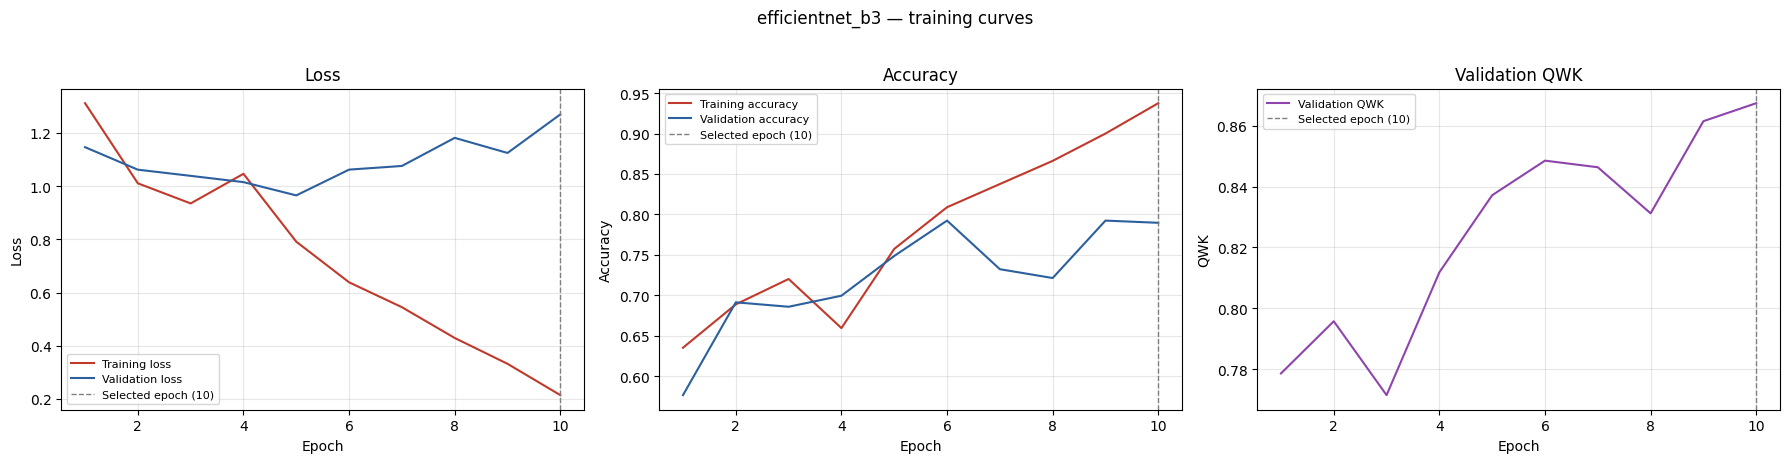

 epoch  phase     lr  train_loss  train_acc  val_loss  val_acc  val_qwk
     1 frozen 0.0001      1.3120     0.6352    1.1466   0.5765   0.7786
     2 frozen 0.0001      1.0107     0.6887    1.0619   0.6913   0.7958
     3 frozen 0.0001      0.9350     0.7201    1.0387   0.6858   0.7715
     4   full 0.0001      1.0464     0.6594    1.0152   0.6995   0.8118
     5   full 0.0001      0.7911     0.7573    0.9652   0.7486   0.8371
     6   full 0.0001      0.6384     0.8089    1.0622   0.7923   0.8485
     7   full 0.0001      0.5448     0.8375    1.0759   0.7322   0.8463
     8   full 0.0001      0.4291     0.8662    1.1816   0.7213   0.8312
     9   full 0.0001      0.3319     0.9000    1.1248   0.7923   0.8615
    10   full 0.0000      0.2142     0.9375    1.2698   0.7896   0.8674


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

axes[0].plot(hist["epoch"], hist["train_loss"], color="#c0392b", label="Training loss")
axes[0].plot(hist["epoch"], hist["val_loss"], color="#2c5f9e", label="Validation loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("Loss")

axes[1].plot(hist["epoch"], hist["train_acc"], color="#c0392b", label="Training accuracy")
axes[1].plot(hist["epoch"], hist["val_acc"], color="#2c5f9e", label="Validation accuracy")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].set_title("Accuracy")

axes[2].plot(hist["epoch"], hist["val_qwk"], color="#8e44ad", label="Validation QWK")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("QWK"); axes[2].set_title("Validation QWK")

for ax in axes:
    ax.axvline(best_epoch, ls="--", c="gray", lw=1, label=f"Selected epoch ({best_epoch})")
    ax.legend(fontsize=8); ax.grid(alpha=.3)

plt.suptitle(f"{CFG.BACKBONE} — training curves", y=1.02)
plt.tight_layout()
plt.savefig(CFG.FIG_DIR / "training_curves.png", dpi=200, bbox_inches="tight")
plt.show()

hist.to_csv(_artifact("training_history.csv"), index=False)
print(hist.round(4).to_string(index=False))

## Cell 12 — Restoring the best checkpoint

In [12]:
ckpt = torch.load(CFG.CKPT_PATH, map_location=CFG.DEVICE, weights_only=False)
model.load_state_dict(ckpt["state_dict"])
model.to(CFG.DEVICE).eval()
print(f"Checkpoint restored: epoch {ckpt['epoch']} | val_loss {ckpt['val_loss']:.4f} | "
      f"val_acc {ckpt['val_acc']:.4f} | val_QWK {ckpt['val_qwk']:.4f}")

Checkpoint restored: epoch 10 | val_loss 1.2698 | val_acc 0.7896 | val_QWK 0.8674


## Cell 13 — Test set evaluation

The test set is evaluated **exactly once**, without test-time augmentation. All metrics below are
computed from `y_pred = argmax(y_prob)`.

In [13]:
test_loss, test_acc, y_prob, y_true = evaluate(model, dl_test, criterion)
y_pred = y_prob.argmax(1)

acc       = accuracy_score(y_true, y_pred)
f1_macro  = f1_score(y_true, y_pred, average="macro")
qwk       = cohen_kappa_score(y_true, y_pred, weights="quadratic")
kappa_lin = cohen_kappa_score(y_true, y_pred, weights="linear")

print(f"Test : n = {len(y_true)} | loss {test_loss:.4f}")
print(f"  Accuracy       : {acc*100:.2f} %")
print(f"  F1 macro       : {f1_macro:.4f}")
print(f"  QWK            : {qwk:.4f}")
print(f"  Linear kappa   : {kappa_lin:.4f}")

pred_df = pd.DataFrame({
    "id_code": df_test["id_code"].values,
    "true": y_true, "pred": y_pred,
    **{f"prob_{i}": y_prob[:, i] for i in range(CFG.N_CLASSES)},
})
pred_df.to_csv(_artifact("test_predictions.csv"), index=False)
pred_df.head()

Test : n = 366 | loss 1.1387
  Accuracy       : 80.87 %
  F1 macro       : 0.6660
  QWK            : 0.9065
  Linear kappa   : 0.8307


,id_code,true,pred,prob_0,prob_1,prob_2,prob_3,prob_4
0,ce754234d760,0,0,0.993382,0.005137,0.001317,1.012370e-04,0.000063
1,668e853258cd,2,2,0.000067,0.016452,0.974105,8.170864e-03,0.001205
2,4384fa687afa,2,4,0.013582,0.228716,0.129131,1.440164e-02,0.614170
3,4d3de40ced3a,0,0,0.999986,0.000006,0.000005,2.907519e-07,0.000003
4,26453eb7e989,2,2,0.000016,0.000925,0.996668,1.430510e-03,0.000961


## Cell 14 — Confusion matrices

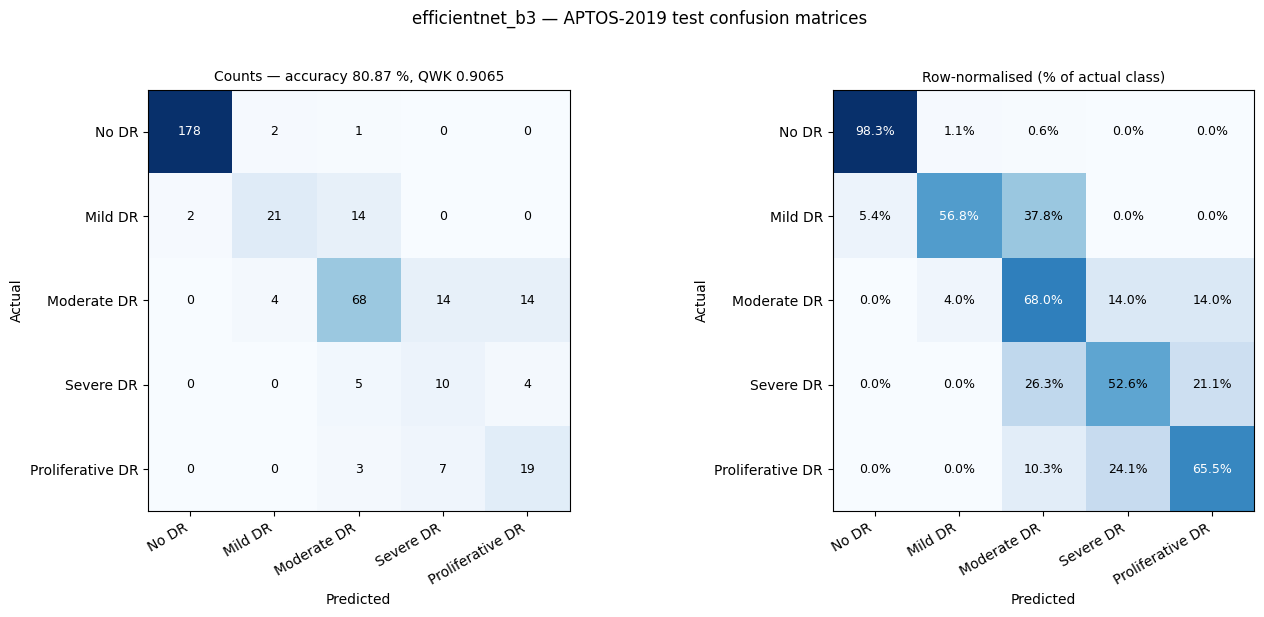

In [14]:
cm     = confusion_matrix(y_true, y_pred, labels=range(CFG.N_CLASSES))
cm_pct = confusion_matrix(y_true, y_pred, labels=range(CFG.N_CLASSES), normalize="true") * 100


def _plot_cm(ax, m: np.ndarray, title: str, pct: bool = False) -> None:
    """Display only: m is already computed by confusion_matrix."""
    ax.imshow(m, cmap="Blues")
    for i in range(CFG.N_CLASSES):
        for j in range(CFG.N_CLASSES):
            v = m[i, j]
            ax.text(j, i, f"{v:.1f}%" if pct else f"{int(v)}", ha="center", va="center",
                    fontsize=9, color="white" if v > m.max() * 0.55 else "black")
    ax.set_xticks(range(CFG.N_CLASSES)); ax.set_yticks(range(CFG.N_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right")
    ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title(title, fontsize=10)


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
_plot_cm(axes[0], cm,     f"Counts — accuracy {acc*100:.2f} %, QWK {qwk:.4f}")
_plot_cm(axes[1], cm_pct, "Row-normalised (% of actual class)", pct=True)
plt.suptitle(f"{CFG.BACKBONE} — APTOS-2019 test confusion matrices", y=1.02)
plt.tight_layout()
plt.savefig(CFG.FIG_DIR / "confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

## Cell 15 — One-vs-rest ROC curves and AUC

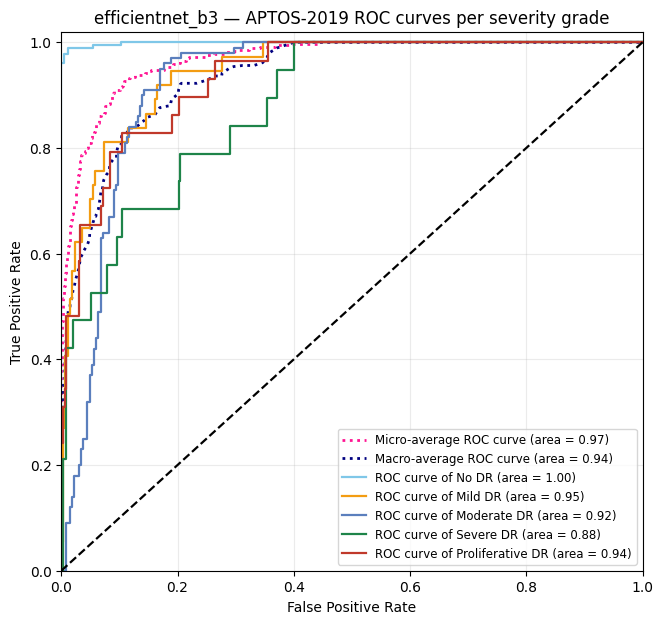

AUC OvR macro 0.9377 | weighted 0.9623 | micro 0.9685


In [15]:
y_bin = label_binarize(y_true, classes=range(CFG.N_CLASSES))

# 1. Areas: all computed with roc_auc_score.
auc_per_class    = roc_auc_score(y_bin, y_prob, average=None)
auc_ovr_macro    = roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro")
auc_ovr_weighted = roc_auc_score(y_true, y_prob, multi_class="ovr", average="weighted")
auc_micro        = roc_auc_score(y_bin, y_prob, average="micro")

# 2. Curves: roc_curve per class and on the flattened one-vs-rest matrix (micro).
fpr, tpr = {}, {}
for i in range(CFG.N_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_prob[:, i])
fpr["micro"], tpr["micro"], _ = roc_curve(y_bin.ravel(), y_prob.ravel())

# sklearn has no macro-average curve: mean of interpolated TPRs, used for plotting only.
# The area shown in the legend is roc_auc_score's, not an integral of this curve.
fpr["macro"] = np.unique(np.concatenate([fpr[i] for i in range(CFG.N_CLASSES)]))
tpr["macro"] = np.mean([np.interp(fpr["macro"], fpr[i], tpr[i])
                        for i in range(CFG.N_CLASSES)], axis=0)

# 3. Figure
plt.figure(figsize=(7.5, 7))
plt.plot(fpr["micro"], tpr["micro"], ls=":", lw=2, color="deeppink",
         label=f"Micro-average ROC curve (area = {auc_micro:.2f})")
plt.plot(fpr["macro"], tpr["macro"], ls=":", lw=2, color="navy",
         label=f"Macro-average ROC curve (area = {auc_ovr_macro:.2f})")
for i, c in enumerate(["#7fc7e8", "#f39c12", "#5b7fbd", "#1e8449", "#c0392b"]):
    plt.plot(fpr[i], tpr[i], color=c, lw=1.6,
             label=f"ROC curve of {CLASS_NAMES[i]} (area = {auc_per_class[i]:.2f})")
plt.plot([0, 1], [0, 1], "k--", lw=1.6)
plt.xlim(0, 1); plt.ylim(0, 1.02)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title(f"{CFG.BACKBONE} — APTOS-2019 ROC curves per severity grade")
plt.legend(loc="lower right", fontsize=8.5); plt.grid(alpha=.25)
plt.savefig(CFG.FIG_DIR / "roc_curve.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"AUC OvR macro {auc_ovr_macro:.4f} | weighted {auc_ovr_weighted:.4f} | micro {auc_micro:.4f}")

## Cell 16 — Full metric set

Every value comes from `sklearn.metrics`. Three blocks: one-vs-rest per-class metrics, averages
(macro / weighted / micro), and referable DR (grade ≥ 1), the most clinically relevant.

sklearn has no "specificity" or "NPV" function. In a binary problem they are the recall and the
precision of the negative class: `recall_score(..., pos_label=0)` and
`precision_score(..., pos_label=0)`. `[IMPL]`

`accuracy_ovr` micro is `accuracy_score` on the flattened one-vs-rest matrix: this is the "micro
accuracy" reported by Herrero-Tudela et al., not to be confused with multiclass accuracy.

In [16]:
labels = list(range(CFG.N_CLASSES))
Y_true = label_binarize(y_true, classes=labels)         # (N, K) one-vs-rest
Y_pred = label_binarize(y_pred, classes=labels)
_kw = dict(zero_division=0)

# --- 1. per class ------------------------------------------------------------
prec, rec, f1_cls, support = precision_recall_fscore_support(
    y_true, y_pred, labels=labels, average=None, **_kw)
mcm = multilabel_confusion_matrix(y_true, y_pred, labels=labels)   # (K,2,2) [[TN,FP],[FN,TP]]

per_class = pd.DataFrame({
    "class": CLASS_NAMES,
    "support": support.astype(int),
    "TP": mcm[:, 1, 1].astype(int), "FP": mcm[:, 0, 1].astype(int),
    "FN": mcm[:, 1, 0].astype(int), "TN": mcm[:, 0, 0].astype(int),
    "sensitivity": rec,
    "specificity": [recall_score(Y_true[:, k], Y_pred[:, k], pos_label=0, **_kw) for k in labels],
    "PPV": prec,
    "NPV": [precision_score(Y_true[:, k], Y_pred[:, k], pos_label=0, **_kw) for k in labels],
    "F1": f1_cls,
    "accuracy_ovr": [accuracy_score(Y_true[:, k], Y_pred[:, k]) for k in labels],
    "AUC": auc_per_class,
})


# --- 2. averages -------------------------------------------------------------
def _avg_row(avg: str) -> dict:
    """One row of averages; `avg` follows sklearn semantics."""
    row = {"sensitivity": recall_score(Y_true, Y_pred, average=avg, **_kw),
           "PPV":         precision_score(Y_true, Y_pred, average=avg, **_kw),
           "F1":          f1_score(Y_true, Y_pred, average=avg, **_kw)}
    if avg == "weighted":
        # On inverted labels (1 - Y), sklearn would weight by N - n_k. We keep the weight n_k,
        # identical to the one used for sensitivity/PPV/F1, applied to sklearn per-class values.
        for m in ("specificity", "NPV", "accuracy_ovr"):
            row[m] = float(np.average(per_class[m], weights=per_class["support"]))
    else:
        row["specificity"] = recall_score(1 - Y_true, 1 - Y_pred, average=avg, **_kw)
        row["NPV"]         = precision_score(1 - Y_true, 1 - Y_pred, average=avg, **_kw)
        # Every column holds N samples: macro and micro averages coincide.
        row["accuracy_ovr"] = accuracy_score(Y_true.ravel(), Y_pred.ravel())
    return row


agg = pd.DataFrame({avg: _avg_row(avg) for avg in ("macro", "weighted", "micro")}).T
agg = agg[["sensitivity", "specificity", "PPV", "NPV", "F1", "accuracy_ovr"]]
macro = agg.loc["macro"].to_dict()

cls_report = classification_report(y_true, y_pred, labels=labels, target_names=CLASS_NAMES,
                                    output_dict=True, **_kw)

print("=== Per-class metrics (one-vs-rest) ===")
print(per_class.drop(columns=["TP", "FP", "FN", "TN"]).round(4).to_string(index=False))
print("\n=== Averages ===")
print(agg.round(4).to_string())

print("\n=== Standard multiclass metrics ===")
print(f"Accuracy      : {acc*100:.2f} %")
print(f"QWK           : {qwk:.4f}")
print(f"Linear kappa  : {kappa_lin:.4f}")
print(f"F1 macro      : {f1_macro:.4f}")
print(f"AUC OvR macro : {auc_ovr_macro:.4f}")

print("\n=== Classification report ===")
print(classification_report(y_true, y_pred, labels=labels, target_names=CLASS_NAMES,
                            digits=4, **_kw))

# --- 3. referable DR (grade >= 1) ----------------------------------------------
ref_true, ref_pred = (y_true >= 1).astype(int), (y_pred >= 1).astype(int)
referable = dict(sensitivity=recall_score(ref_true, ref_pred, pos_label=1, **_kw),
                 specificity=recall_score(ref_true, ref_pred, pos_label=0, **_kw),
                 PPV=precision_score(ref_true, ref_pred, pos_label=1, **_kw),
                 NPV=precision_score(ref_true, ref_pred, pos_label=0, **_kw),
                 accuracy=accuracy_score(ref_true, ref_pred),
                 AUC=roc_auc_score(ref_true, y_prob[:, 1:].sum(1)))
print("=== Referable DR (>= Mild) ===")
print(pd.Series(referable).round(4).to_string())

=== Per-class metrics (one-vs-rest) ===
           class  support  sensitivity  specificity    PPV    NPV     F1  accuracy_ovr    AUC
           No DR      181       0.9834       0.9892 0.9889 0.9839 0.9861        0.9863 0.9989
         Mild DR       37       0.5676       0.9818 0.7778 0.9528 0.6562        0.9399 0.9464
     Moderate DR      100       0.6800       0.9135 0.7473 0.8836 0.7120        0.8497 0.9248
       Severe DR       19       0.5263       0.9395 0.3226 0.9731 0.4000        0.9180 0.8832
Proliferative DR       29       0.6552       0.9466 0.5135 0.9696 0.5758        0.9235 0.9353

=== Averages ===
          sensitivity  specificity     PPV     NPV      F1  accuracy_ovr
macro          0.6825       0.9541  0.6700  0.9526  0.6660        0.9235
weighted       0.8087       0.9618  0.8293  0.9517  0.8150        0.9358
micro          0.8087       0.9522  0.8087  0.9522  0.8087        0.9235

=== Standard multiclass metrics ===
Accuracy      : 80.87 %
QWK           : 0.9065
Li

## Cell 17 — Bootstrap confidence intervals

With n = 366, the 95 % CI of the QWK is roughly ±0.03 and that of the accuracy roughly ±3.5 points.
Differences between models smaller than these margins are not interpretable.

In [17]:
def bootstrap_ci(y_true: np.ndarray, y_pred: np.ndarray, n_boot: int = 2000,
                 seed: int = CFG.SEED) -> dict:
    """95 % percentile CI for accuracy, QWK and macro F1."""
    rng = np.random.default_rng(seed)
    n = len(y_true)
    stats = {"accuracy": [], "qwk": [], "f1_macro": []}
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        stats["accuracy"].append(accuracy_score(y_true[idx], y_pred[idx]))
        stats["qwk"].append(cohen_kappa_score(y_true[idx], y_pred[idx], weights="quadratic"))
        stats["f1_macro"].append(f1_score(y_true[idx], y_pred[idx], average="macro", zero_division=0))
    out = {}
    for k, v in stats.items():
        out[k] = (float(np.percentile(v, 2.5)), float(np.percentile(v, 97.5)))
        out[f"{k}_std"] = float(np.std(v))
    return out


boot = bootstrap_ci(y_true, y_pred)
for k, point in (("accuracy", acc), ("qwk", qwk), ("f1_macro", f1_macro)):
    lo, hi = boot[k]
    print(f"{k:9s} {point:.4f}  95 % CI [{lo:.4f}, {hi:.4f}]  (std {boot[k + '_std']:.4f})")

accuracy  0.8087  95 % CI [0.7678, 0.8470]  (std 0.0201)
qwk       0.9065  95 % CI [0.8807, 0.9277]  (std 0.0122)
f1_macro  0.6660  95 % CI [0.5982, 0.7210]  (std 0.0311)


## Cell 18 — Grad-CAM++

Grad-CAM weights each activation channel by the spatial mean of the gradients of the target score.
Grad-CAM++ replaces this uniform mean with a pixel-wise weighting:

$$\alpha^{kc}_{ij} = \frac{(\partial_{ij} S^c)^2}
{2(\partial_{ij} S^c)^2 + \sum_{ab} A^k_{ab}\,(\partial_{ab} S^c)^3},
\qquad w^c_k = \sum_{ij} \alpha^{kc}_{ij}\,\mathrm{ReLU}(\partial_{ij} S^c)$$

Practical consequence: when several small lesions contribute to the same score, Grad-CAM's uniform
mean dilutes their contribution and highlights only one; Grad-CAM++ keeps them all. This is the
typical situation of scattered microaneurysms, hence the choice of this method for every
architecture in the project.

The target is the logit of the predicted grade (or of a chosen grade via `class_idx`). Maps require
gradients: mixed precision is not used here and images are processed one at a time.

In [18]:
class GradCAM:
    """Grad-CAM: channels weighted by the spatial mean of the gradients."""

    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model
        self.acts = None
        self.grads = None
        self._handles = [target_layer.register_forward_hook(self._forward_hook)]

    def _forward_hook(self, module, inp, out):
        self.acts = out
        # Hooks stay attached during torch.no_grad() passes, where no gradient hook can be
        # registered on the output.
        if out.requires_grad:
            out.register_hook(self._save_grad)

    def _save_grad(self, grad):
        self.grads = grad

    def remove(self) -> None:
        for h in self._handles:
            h.remove()

    def _channel_weights(self, acts: torch.Tensor, grads: torch.Tensor) -> torch.Tensor:
        """-> (B, C, 1, 1)."""
        return grads.mean(dim=(2, 3), keepdim=True)

    def __call__(self, x: torch.Tensor, class_idx: int = None) -> np.ndarray:
        """-> (B, H, W) map normalised to [0, 1]."""
        self.model.zero_grad(set_to_none=True)
        logits = self.model(x)
        idx = logits.argmax(1) if class_idx is None else \
              torch.full((x.size(0),), class_idx, device=x.device, dtype=torch.long)
        logits.gather(1, idx.view(-1, 1)).sum().backward()

        weights = self._channel_weights(self.acts, self.grads)
        raw = (weights * self.acts).sum(dim=1, keepdim=True)
        cam = F.relu(raw)
        if float(cam.detach().abs().max()) == 0.0:
            cam = raw.abs()          # fallback when the ReLU zeroes the whole map
        cam = F.interpolate(cam, size=x.shape[-2:], mode="bilinear", align_corners=False)
        cam = cam.squeeze(1)
        flat = cam.flatten(1)
        lo = flat.min(1)[0].view(-1, 1, 1)
        hi = flat.max(1)[0].view(-1, 1, 1)
        return ((cam - lo) / (hi - lo + 1e-8)).detach().cpu().numpy()


class GradCAMPlusPlus(GradCAM):
    """Grad-CAM++: pixel-wise weighting of the positive gradients."""

    def _channel_weights(self, acts: torch.Tensor, grads: torch.Tensor) -> torch.Tensor:
        g2, g3 = grads.pow(2), grads.pow(3)
        denom = 2.0 * g2 + (acts.sum(dim=(2, 3), keepdim=True) * g3)
        alpha = g2 / torch.where(denom.abs() < 1e-12, torch.full_like(denom, 1e-12), denom)
        alpha = alpha * (grads != 0)          # alpha is undefined where the gradient is zero
        return (alpha * F.relu(grads)).sum(dim=(2, 3), keepdim=True)


CAM_CLASSES = {"gradcam": GradCAM, "gradcam++": GradCAMPlusPlus}
CAM_LABEL = {"gradcam": "Grad-CAM", "gradcam++": "Grad-CAM++"}[CFG.CAM_METHOD]


def overlay_cam(img_uint8: np.ndarray, cam: np.ndarray, alpha: float = 0.45) -> np.ndarray:
    """Overlay a [0, 1] map on the RGB image with a jet colormap."""
    heat = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heat = cv2.cvtColor(heat, cv2.COLOR_BGR2RGB)
    return np.uint8((1 - alpha) * img_uint8 + alpha * heat)


def cam_for_index(i: int):
    """-> (uint8 image, CAM of the predicted grade, true grade, predicted grade)."""
    x, y = ds_test[i]
    x = x.unsqueeze(0).to(CFG.DEVICE)
    cam = cam_engine(x)[0]
    with torch.no_grad():
        pred = model(x).argmax(1).item()
    return denormalize(x[0]), cam, y, pred


model.eval()
cam_engine = CAM_CLASSES[CFG.CAM_METHOD](model, cam_layer)
print(f"{CAM_LABEL} attached to {CFG.BACKBONE}.{CFG.CAM_LAYER}")

Grad-CAM++ attached to efficientnet_b3.bn2


## Cell 19 — Figure 1: one correctly classified case per grade

For each grade, the most confident correct prediction, for a readable explanation.

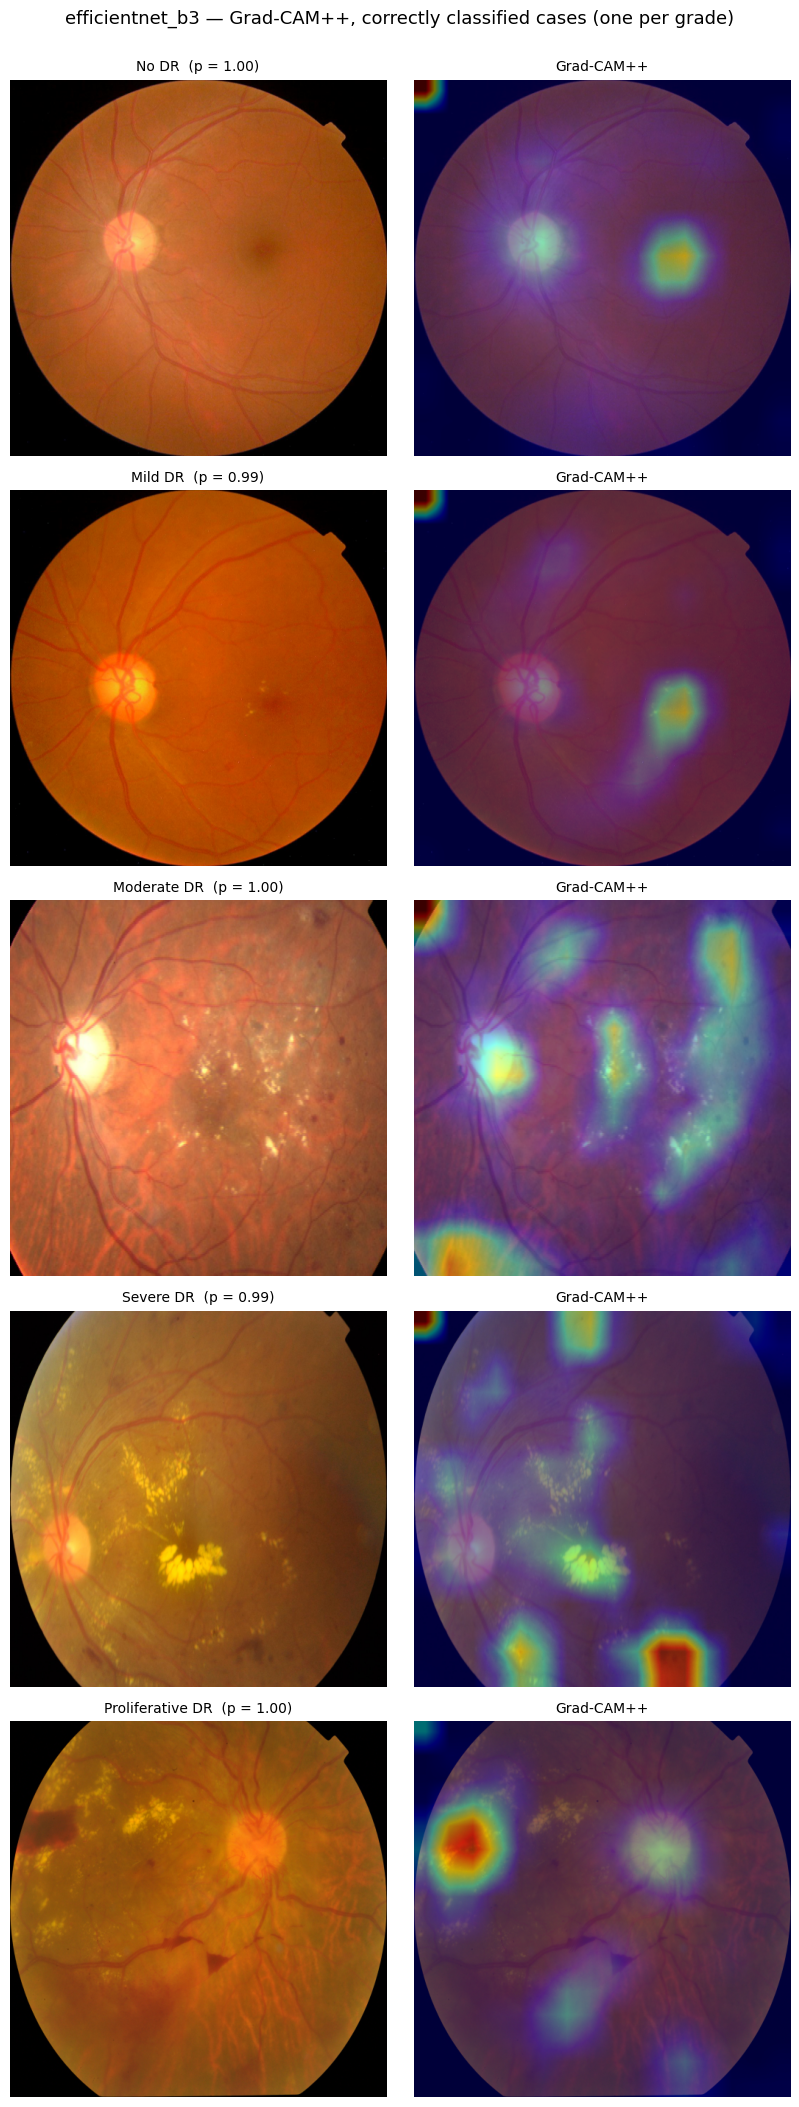

In [19]:
correct = [np.where((y_true == c) & (y_pred == c))[0] for c in range(CFG.N_CLASSES)]

fig, axes = plt.subplots(CFG.N_CLASSES, 2, figsize=(8.4, 4.2 * CFG.N_CLASSES))
for c in range(CFG.N_CLASSES):
    if len(correct[c]) == 0:
        for j in range(2):
            axes[c, j].text(.5, .5, f"No correct case\n{CLASS_NAMES[c]}", ha="center", va="center")
            axes[c, j].axis("off")
        continue

    i = int(correct[c][np.argmax(y_prob[correct[c], c])])
    img, cam, _, _ = cam_for_index(i)
    axes[c, 0].imshow(img)
    axes[c, 0].set_title(f"{CLASS_NAMES[c]}  (p = {y_prob[i, c]:.2f})", fontsize=10)
    axes[c, 1].imshow(overlay_cam(img, cam))
    axes[c, 1].set_title(CAM_LABEL, fontsize=10)
    for j in range(2):
        axes[c, j].axis("off")

plt.suptitle(f"{CFG.BACKBONE} — {CAM_LABEL}, correctly classified cases (one per grade)",
             y=1.001, fontsize=13)
plt.tight_layout()
plt.savefig(CFG.FIG_DIR / "cam_correct.png", dpi=180, bbox_inches="tight")
plt.show()

## Cell 20 — Figure 2: misclassifications

Maps on failures are more informative than on successes: they show whether the model looks at the
wrong region, or at the right region and still gets the grade wrong. Errors with the largest
magnitude (`|actual − predicted|`) are shown first.

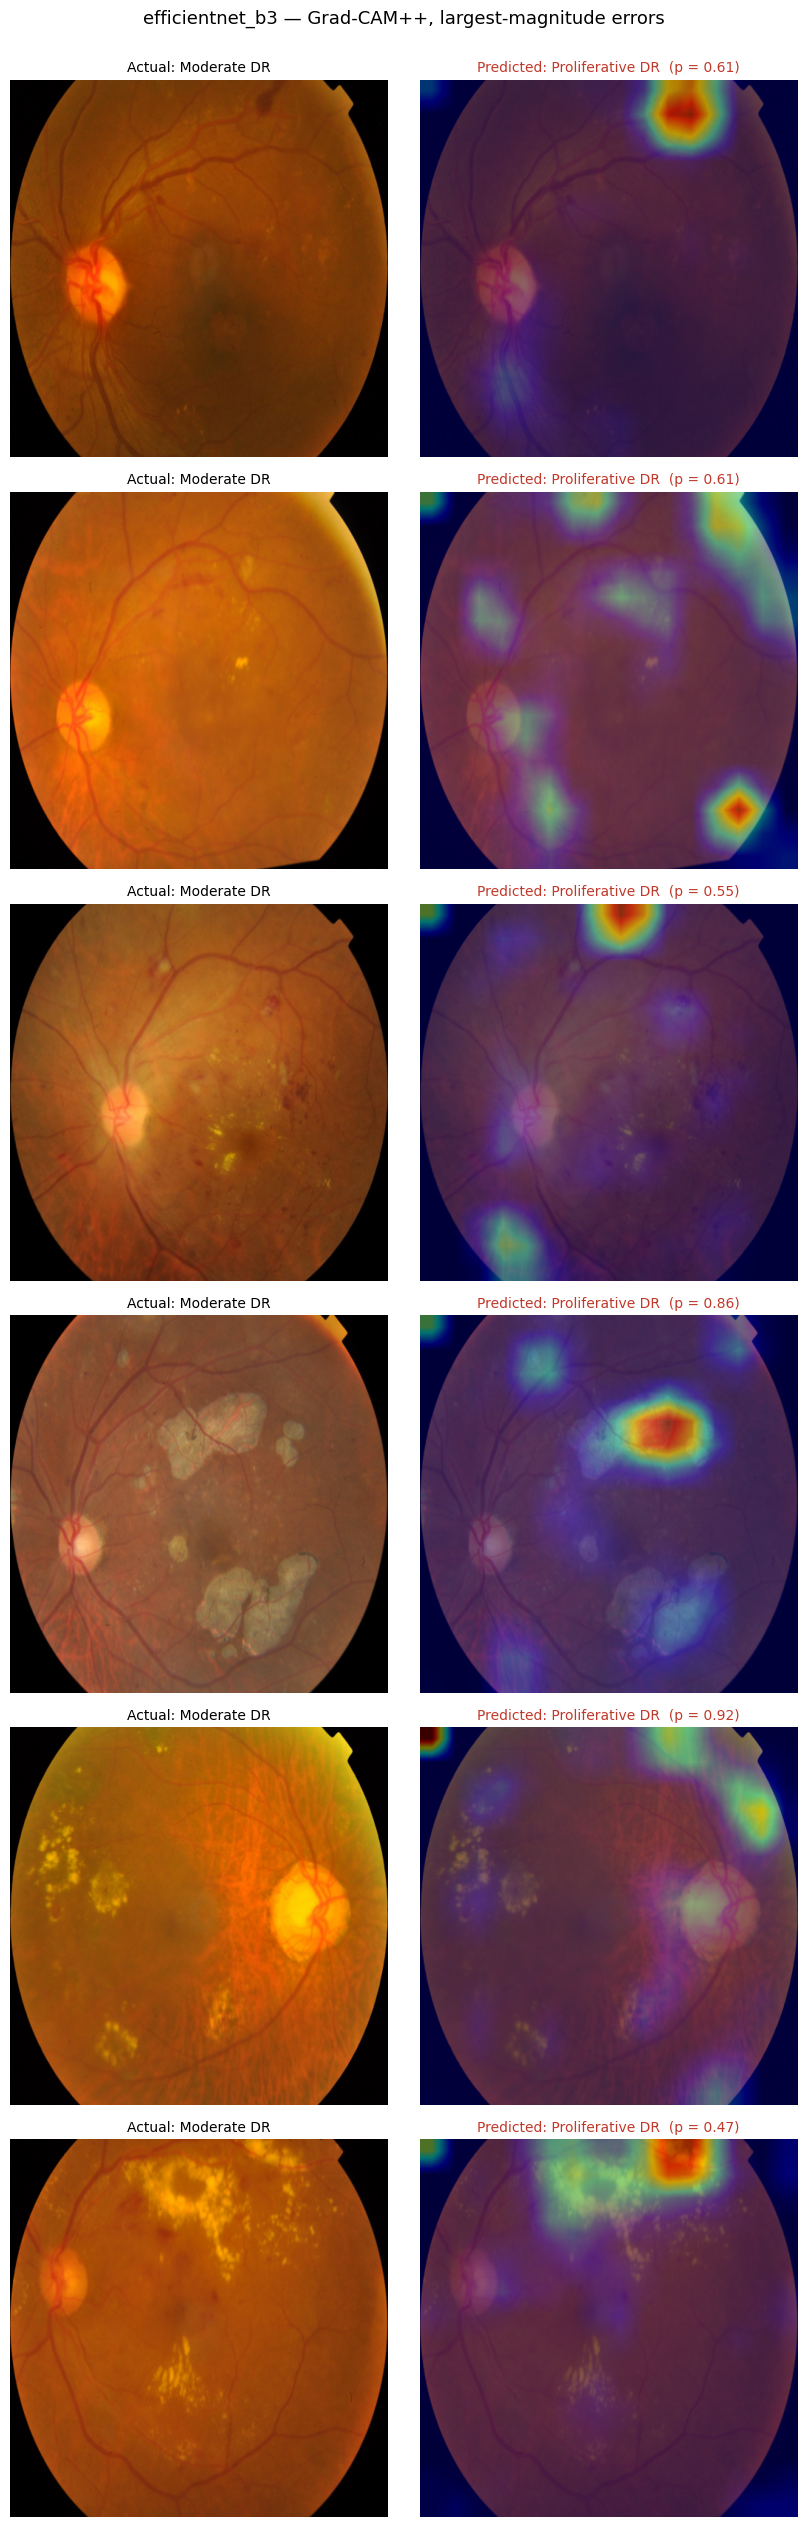

In [20]:
errors = np.where(y_true != y_pred)[0]
n_show = min(6, len(errors))

if n_show == 0:
    print("No misclassification.")
else:
    order = errors[np.argsort(-np.abs(y_true[errors] - y_pred[errors]), kind="stable")][:n_show]
    fig, axes = plt.subplots(n_show, 2, figsize=(8.6, 4.2 * n_show))
    axes = np.atleast_2d(axes)

    for r, i in enumerate(order):
        img, cam, yt, yp = cam_for_index(int(i))
        axes[r, 0].imshow(img)
        axes[r, 0].set_title(f"Actual: {CLASS_NAMES[yt]}", fontsize=10)
        axes[r, 1].imshow(overlay_cam(img, cam))
        axes[r, 1].set_title(f"Predicted: {CLASS_NAMES[yp]}  (p = {y_prob[i, yp]:.2f})",
                             fontsize=10, color="#c0392b")
        for j in range(2):
            axes[r, j].axis("off")

    plt.suptitle(f"{CFG.BACKBONE} — {CAM_LABEL}, largest-magnitude errors", y=1.001, fontsize=13)
    plt.tight_layout()
    plt.savefig(CFG.FIG_DIR / "cam_errors.png", dpi=180, bbox_inches="tight")
    plt.show()

## Cell 21 — Figure 3: class sensitivity on the same image

The same retina explained from the point of view of each of the 5 grades. A model that has learned a
notion of severity should shift its attention from one grade to another; identical maps would mean
the head does not discriminate spatially.

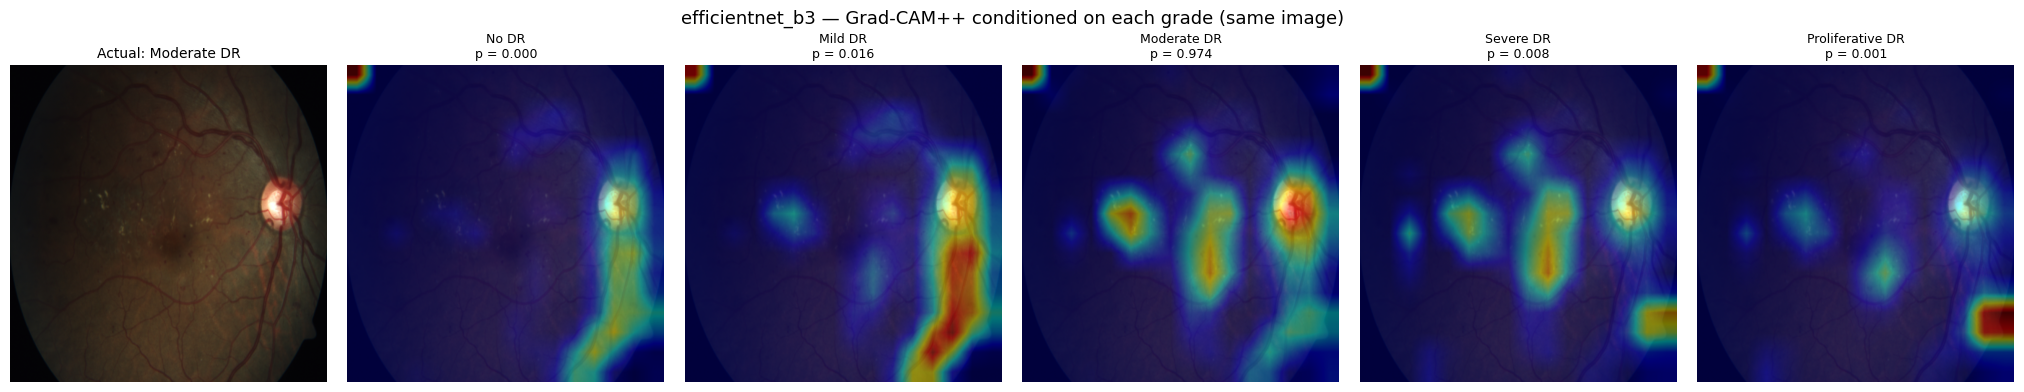

In [21]:
cand = np.where((y_true >= 2) & (y_true == y_pred))[0]
i = int(cand[0]) if len(cand) else int(np.argmax(y_true))

x, _ = ds_test[i]
x = x.unsqueeze(0).to(CFG.DEVICE)
img = denormalize(x[0])

fig, axes = plt.subplots(1, CFG.N_CLASSES + 1, figsize=(3.4 * (CFG.N_CLASSES + 1), 3.8))
axes[0].imshow(img); axes[0].axis("off")
axes[0].set_title(f"Actual: {CLASS_NAMES[y_true[i]]}", fontsize=10)

for c in range(CFG.N_CLASSES):
    cam_c = cam_engine(x, class_idx=c)[0]
    axes[c + 1].imshow(overlay_cam(img, cam_c)); axes[c + 1].axis("off")
    axes[c + 1].set_title(f"{CLASS_NAMES[c]}\np = {y_prob[i, c]:.3f}", fontsize=9)

plt.suptitle(f"{CFG.BACKBONE} — {CAM_LABEL} conditioned on each grade (same image)",
             y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(CFG.FIG_DIR / "cam_per_class.png", dpi=180, bbox_inches="tight")
plt.show()

cam_engine.remove()   # detach the hooks

## Cell 22 — Saving the results

`metrics.json` holds the whole run: configuration, preprocessing inherited from notebook `00`,
split fingerprints, epoch-by-epoch history, test metrics, bootstrap CIs, per-class metrics,
referable DR and confusion matrix. The file is self-contained.

Two identical copies are written: `/kaggle/working/metrics.json` and
`results/metrics/<MODEL_NAME>.json`, the file name expected by `08_model_comparison`.

In [22]:
best_row = hist.loc[hist["epoch"] == best_epoch].iloc[0]

metrics = {
    "run": {"model": CFG.MODEL_NAME, "backbone": CFG.BACKBONE, "family": CFG.FAMILY,
            "head": "single", "seed": CFG.SEED, "img_size": CFG.IMG_SIZE,
            "select_on": CFG.SELECT_ON, "cam_method": CFG.CAM_METHOD,
            "cam_layer": f"backbone.{CFG.CAM_LAYER}",
            "n_params_total": int(n_tot), "n_params_head": int(n_head),
            "n_features": int(model.backbone.num_features),
            "timestamp": time.strftime("%Y-%m-%d %H:%M:%S")},
    "data": {"prep_dir": str(prep_dir), "preprocessing": prep_cfg, "split_sha1": split_sha1},
    "split": {"train": len(df_train), "val": len(df_val), "test": len(df_test),
              "test_class_counts": np.bincount(y_true, minlength=CFG.N_CLASSES).tolist()},
    "training": {"epochs_run": int(len(hist)), "best_epoch": int(best_epoch),
                 "minutes": round(float(train_minutes), 2),
                 "best_val_loss": float(stopper.best),
                 "val_qwk_at_best": float(best_row["val_qwk"]),
                 "val_acc_at_best": float(best_row["val_acc"]),
                 "history": hist.to_dict("records")},
    "test": {"n": int(len(y_true)), "loss": float(test_loss),
             "accuracy": float(acc), "f1_macro": float(f1_macro),
             "qwk": float(qwk), "kappa_linear": float(kappa_lin),
             "auc_ovr_macro": float(auc_ovr_macro), "auc_ovr_weighted": float(auc_ovr_weighted),
             "auc_micro": float(auc_micro),
             "auc_per_class": [float(a) for a in auc_per_class]},
    "bootstrap_ci95": boot,
    "averages": {k: {kk: float(vv) for kk, vv in v.items()}
                 for k, v in agg.to_dict("index").items()},
    "per_class": per_class.to_dict("records"),
    "classification_report": cls_report,
    "referable_dr": {k: float(v) for k, v in referable.items()},
    "confusion_matrix": cm.tolist(),
    "class_names": CLASS_NAMES,
    "config": {k: str(v) for k, v in vars(CFG).items() if not k.startswith("_")},
}

for out_json in (CFG.WORK_DIR / "metrics.json", CFG.METRIC_DIR / f"{CFG.MODEL_NAME}.json"):
    with open(out_json, "w") as f:
        json.dump(metrics, f, indent=2, ensure_ascii=False)

summary = pd.DataFrame([
    ["Multiclass accuracy (%)",       f"{acc*100:.2f}"],
    ["QWK",                           f"{qwk:.4f}"],
    ["F1 macro",                      f"{f1_macro:.4f}"],
    ["AUC (OvR macro)",               f"{auc_ovr_macro:.4f}"],
    ["Macro sensitivity (%)",         f"{macro['sensitivity']*100:.2f}"],
    ["Referable DR — sensitivity (%)", f"{referable['sensitivity']*100:.2f}"],
    ["Referable DR — specificity (%)", f"{referable['specificity']*100:.2f}"],
    ["Epochs run",                    f"{len(hist)} (best: {best_epoch})"],
], columns=["Metric", f"{CFG.BACKBONE} (s{CFG.SEED})"])

print("=" * 80)
print(f"{CFG.BACKBONE} single head — APTOS-2019, test n={len(y_true)}, seed {CFG.SEED}")
print("=" * 80)
print(summary.to_string(index=False))
print("=" * 80)
summary.to_csv(_artifact("final_summary.csv"), index=False)

print()
for f in sorted(p for p in CFG.WORK_DIR.rglob("*") if p.is_file()):
    print(f"{str(f.relative_to(CFG.WORK_DIR)):<55} {f.stat().st_size / 1024:9.1f} KB")

efficientnet_b3 single head — APTOS-2019, test n=366, seed 42
                        Metric efficientnet_b3 (s42)
       Multiclass accuracy (%)                 80.87
                           QWK                0.9065
                      F1 macro                0.6660
               AUC (OvR macro)                0.9377
         Macro sensitivity (%)                 68.25
Referable DR — sensitivity (%)                 98.92
Referable DR — specificity (%)                 98.34
                    Epochs run         10 (best: 10)

__notebook__.ipynb                                         5942.7 KB
checkpoints/efficientnet_b3_s42.pth                       54672.2 KB
metrics.json                                                 10.3 KB
results/figures/efficientnet_b3/cam_correct.png            4319.6 KB
results/figures/efficientnet_b3/cam_errors.png             4791.3 KB
results/figures/efficientnet_b3/cam_per_class.png          1365.9 KB
results/figures/efficientnet_b3/confusion_matr